**PROJECT: FACE DETECTION SYSTEM FOR A DIGITAL CAMERA**



**1. Program Imports**

In [ ]:
# sklearn-related imports
from sklearn.datasets import fetch_lfw_people, fetch_olivetti_faces
from sklearn.feature_extraction.image import PatchExtractor
from skimage.transform import integral_image, resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from skimage import data, transform, color
from skimage.feature import (
    haar_like_feature,
    haar_like_feature_coord,
    hog,
    daisy,
    ORB,
)

# sklearn machine learning algorithms
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# generic imports useful for the execution
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import psutil
import time

In [ ]:
# set the feature extractor that will be used
FEATURE_EXTRACTOR = 'hog' #@param ["haar", "hog", "daisy", "orb"]

# set the machine learning algorithm that will be used
MACHINE_LEARNING_ALGO = 'mlp' #@param ["mlp", "nearest_neighbors", "linear_svm", "decision_tree", "random_forest", "naive_bayes", "qda"]

# whether to shuffle the data
SHUFFLE = True

# the seed that will be used for the entire exection
SEED = 42

# number of images per class (for negative samples)
# helps in balancing the positive-negative ratio
N_IMGS_PER_CLASS = 1000

# set the RAM usage at the beginning of the script, in order to
# compute, at the end, only the RAM occupied by the script
BASE_RAM_JUPYTER_NOTEBOOK = dict(psutil.virtual_memory()._asdict())['used']


In [ ]:
# initialize the seed (important for reproducibility)
np.random.seed(SEED)
print(f'Seed {SEED} used to initialize numpy library')

Seed 42 used to initialize numpy library


In [ ]:
class ResourceStatistics():
    """
    Tracks resource usage (i.e., RAM, CPU, execution time) during notebook execution
    """
    def __init__(self) -> None:
        # the total execution time elapsed from the creation
        # of the class element to the end of the notebook
        self.total_running_time = -time.time()
        # dicts of resource consumptions
        self.ram_usage = {}
        self.cpu_percent = {}
        self.stats_exec_times = {}
        self.stats_ram_usage = {}
        self.stats_cpu_percent = {}

    def compute_statistics(self):
        """Updates current CPU and RAM usage."""
        # get the current total execution time
        cur_tot_exec_time = self.total_running_time + time.time()
        # compute CPU percentage
        cpu_percent = psutil.cpu_percent()
        self.cpu_percent[f'{cur_tot_exec_time}'] = cpu_percent
        # compute RAM usage
        ram_usage = dict(psutil.virtual_memory()._asdict())['used'] / (1024.0 ** 3)
        self.ram_usage[f'{cur_tot_exec_time}'] = ram_usage
        return cpu_percent, ram_usage

    def start_stats_profiling(self, stat: str):
        """Starts profiling for a code section."""
        cpu_percent, ram_usage = self.compute_statistics()
        cur_exec_time = -time.time()
        self.stats_exec_times[stat] = cur_exec_time
        self.stats_cpu_percent[stat] = -cpu_percent
        self.stats_ram_usage[stat] = -ram_usage

    def stop_stats_profiling(self, stat: str):
        """
        The statistics computes the used RAM and CPU percent
        and it is computed as delta_ram = (end_ram - start_ram)
        similarly happens for the CPU percent therefore, the
        delta values can also be negative, if the RAM is freed or
        the ending CPU consumption is lower than the beginning
        """
        cpu_percent, ram_usage = self.compute_statistics()
        self.stats_exec_times[stat] += time.time()
        self.stats_cpu_percent[stat] += cpu_percent
        self.stats_ram_usage[stat] += ram_usage

    def print_stats_profile(self, stat: str):
        """Prints collected statistics for a section."""
        cpu_percent = self.stats_cpu_percent[stat]
        ram_usage = self.stats_ram_usage[stat]
        exec_time = self.stats_exec_times[stat]
        print(f'\n---------- {stat} Statistics ----------')
        print(f'|   Time Elaps. : {np.around(exec_time,2)} sec')
        print(f'|   CPU used : {np.around(cpu_percent,2)} %')
        print(f'|   RAM used : {np.around(ram_usage,2)} GBs')

    def program_end(self):
        """Returns total execution time of the whole notebook."""
        self.total_running_time += time.time()
        return self.total_running_time

In [ ]:
res_stats = ResourceStatistics()

**2. Dataset Gathering**


We will make use of a real dataset of faces, to be used for the ML model training. As stated in https://www.kaggle.com/datasets/jessicali9530/lfw-dataset :

Labeled Faces in the Wild (LFW) is a database of face photographs designed for studying the problem of unconstrained face recognition. This database was created and maintained by researchers at the University of Massachusetts, Amherst (specific references are in Acknowledgments section). 13 233 images of 5 749 people were detected and centered by the Viola Jones face detector and collected from the web. 1 680 of the people pictured have two or more distinct photos in the dataset. The original database contains four different sets of LFW images and also three different types of "aligned" images. According to the researchers, deep-funneled images produced superior results for most face verification algorithms compared to the other image types. Hence, the dataset uploaded here is the deep-funneled version.

### Gathering Positive Samples

Positive samples will contain the faces coming from the LFW dataset

In [ ]:
pos_stats = 'Positive Samples Generation'
res_stats.start_stats_profiling(pos_stats)

# we will use the LFW (Labeled Faces in the Wild) dataset
print("Loading Faces images (Positive Samples)...")
lfw_people = fetch_lfw_people()
positive_patches = lfw_people.images
print(f"   ...loaded {len(positive_patches)} samples")
num_samples = len(positive_patches)
image_size = positive_patches[0].shape

res_stats.stop_stats_profiling(pos_stats)
res_stats.print_stats_profile(pos_stats)

Loading Faces images (Positive Samples)...
   ...loaded 13233 samples

---------- Positive Samples Generation Statistics ----------
|   Time Elaps. : 1.12 sec
|   CPU used : 91.5 %
|   RAM used : 0.04 GBs


### Gathering Negative Samples

Regarding the Negative samples, they can be produced using

Next we need a set of similarly sized thumbnails which do not have a face in them. One way to do this is to take any corpus of input images, and extract thumbnails from them at a variety of scales. Here we can use some of the images shipped with Scikit-Image, along with Scikit-Learn's PatchExtractor:

In [ ]:
# NOTE: with this set of negative images,
# the negative samples will be more complex,
# and therefore the tuning of the ML model
# is more complicated on low resources system.
# imgs_to_use = [
#     'binary_blobs', 'brick', 'camera', 'cat', 'cell', 'cells3d', 'checkerboard',
#     'chelsea', 'clock', 'coffee', 'coins', 'colorwheel', 'eagle', 'grass',
#     'gravel', 'horse', 'hubble_deep_field', 'human_mitosis',
#     'immunohistochemistry', 'kidney', 'microaneurysms', 'moon', 'page',
#     'protein_transport', 'retina', 'rocket', 'shepp_logan_phantom', 'skin', 'text',
# ]

# get some non-face images
# to use as negative samples
imgs_to_use = [
    'camera', 'text', 'coins', 'moon', 'page', 'clock', 'immunohistochemistry', 'chelsea', 'coffee', 'hubble_deep_field',
]

In [ ]:
# get the images from data (both RGB and Grayscale)
images = [getattr(data, name)() for name in imgs_to_use]

# convert the only the RGB images to grayscale
images = []
for name in imgs_to_use:
    image = getattr(data, name)()
    if len(image.shape) == 3:
        image = color.rgb2gray(image)
    elif len(image.shape) == 4:
        continue
    images.append(image)

In [ ]:
def extract_patches(
    img: np.array,            # 2D image of dimension MxN
    N: int,                   # number of patches to draw from the image
    patch_size: tuple[int],   # size of each patch
    scale: float = 1.0,       # scale of the patch
    random_state: int = 42,   # seed for the extractor randomness
):
    """
    Extracts `N` the patches from the provided image,
    using the Scikit-Learn PatchExtractor module.

    """
    extracted_patch_size = tuple((scale * np.array(patch_size)).astype(int))
    extractor = PatchExtractor(
        patch_size = extracted_patch_size,
        max_patches = N,
        random_state = random_state
    )
    try:
        patches = extractor.transform(img[np.newaxis])
        if scale != 1:
            patches = np.array([transform.resize(patch, patch_size) for patch in patches])
    except Exception as e:
      patches = np.array(np.random.random(size=(0, *patch_size)))
    return patches


In [ ]:
# Set the scale of the sampled images
# in order to vary the resolution of
# the sampled non face images
scales = [0.5, 1.0, 2.0]

neg_stats = 'Negative Samples Generation'
res_stats.start_stats_profiling(neg_stats)

print("Loading non-Faces images (Negative Samples)...")
negative_patches = np.concatenate([
    extract_patches(im, N_IMGS_PER_CLASS, image_size, scale)
    for im in images for scale in scales], axis=0)
print(f"   ...loaded {len(negative_patches)} samples")

res_stats.stop_stats_profiling(neg_stats)
res_stats.print_stats_profile(neg_stats)

Loading non-Faces images (Negative Samples)...
   ...loaded 30000 samples

---------- Negative Samples Generation Statistics ----------
|   Time Elaps. : 5.99 sec
|   CPU used : -11.7 %
|   RAM used : 0.11 GBs


### Data Visualization

Let's visualize some samples coming from both the datasets

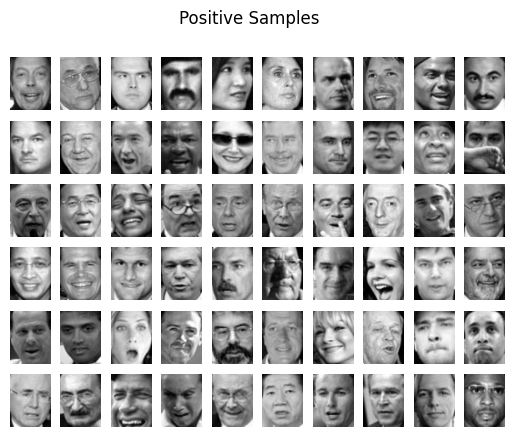

In [ ]:
fig, ax = plt.subplots(6, 10)
fig.suptitle(f'Positive Samples')
for i, axi in enumerate(ax.flat):
    axi.imshow(positive_patches[i], cmap='gray')
    axi.axis('off')

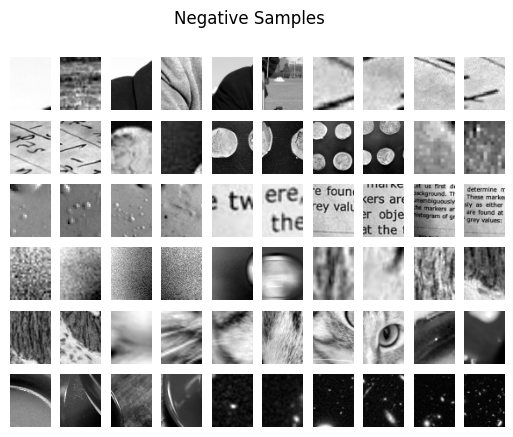

In [ ]:
fig, ax = plt.subplots(6, 10)
fig.suptitle(f'Negative Samples')
for i, axi in enumerate(ax.flat):
    axi.imshow(negative_patches[500 * i], cmap='gray')
    axi.axis('off')

**3. Machine Learning Model**

### Feature Extraction

Here we implement several lightweight feature extractors that can be used to extract meaningful features from the passed images. There are several algorithms implemented:

- **Haar-like Features** - Haar-like features are simple rectangular features that capture the difference in intensity between adjacent regions of an image. They are computed using the integral image, which allows for fast calculation of sums over rectangular areas. These features are commonly used in face detection (e.g., Viola-Jones algorithm) because they can efficiently capture edge, line, and center-surround patterns typical of facial structures.

- **Histogram of Oriented Gradients (HOG) Features** - HOG features describe the distribution of gradient orientations (edge directions) within localized portions of an image. The image is divided into small cells, and for each cell, a histogram of gradient directions is computed. These histograms are then normalized over larger blocks to improve invariance to illumination and contrast. HOG is widely used for object detection, especially for faces, as it captures shape and edge information.

- **DAISY Features** - DAISY features are dense descriptors inspired by SIFT, designed for fast computation and matching. For each pixel, DAISY computes histograms of gradient orientations in concentric rings around the pixel, resulting in a descriptor that is robust to scale and rotation. DAISY is useful for dense matching and recognition tasks.

- **ORB Features** - ORB (Oriented FAST and Rotated BRIEF) is a fast keypoint detector and descriptor. It first detects keypoints using the FAST algorithm, then computes binary descriptors using the BRIEF algorithm, with added orientation and rotation invariance. ORB is efficient and suitable for real-time applications, and its binary descriptors are useful for matching and recognition.

In [ ]:
# # # # HAAR-LIKE EXTRACTOR PARAMS
# set the haar image size
haar_size = 8
# get height and width from the image
height, width = image_size
# select the feature types for the Haar-like feature extraction
feature_types = ['type-4']
# get the feature coords and feature types with this setting
feature_coord, feature_type = haar_like_feature_coord(height=haar_size, width=haar_size, feature_type=feature_types)

def extract_haar_features(
    image: np.array,
    feature_coord: np.array = feature_coord,
    feature_type: np.array = feature_type,
):
    """
    Extract Haar-like features from an image.
    """
    # given the passed parameters, extract the haar features
    iimage = integral_image(image)
    iimage = resize(iimage, (haar_size, haar_size))
    features = haar_like_feature(iimage, r=0, c=0, width=haar_size, height=haar_size, feature_type=feature_type, feature_coord=feature_coord)
    return features

def extract_hog_features(image):
    """
    Extract Histogram of Oriented Gradients (HOG) features from an image.

    HOG features capture the edge and gradient information which is useful
    for object detection tasks like face recognition.
    """
    # Extract HOG features with specified parameters:
    # - 9 orientation bins for gradient directions
    # - 8x8 pixel cells
    # - 2x2 cell blocks for normalization
    features = hog(image, orientations=9, pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2), visualize=False)
    return features

def extract_daisy_features(image: np.array):
    """Extracts DAISY features from an image."""
    return daisy(image).reshape(-1)

# # # # ORB EXTRACTOR PARAMS
orb_extractor = ORB()

def extract_orb_features(image: np.array):
    """Extracts ORB features from an image."""
    orb_extractor.detect_and_extract(image)
    return orb_extractor.descriptors.reshape(-1)

def extract_features(image, feature_extractor):
    """
    Extracts features from an image based on the provided feature extractor.
    """
    if feature_extractor == 'haar':
        return extract_haar_features(image)
    elif feature_extractor == 'hog':
        return extract_hog_features(image)
    elif feature_extractor == 'daisy':
        return extract_daisy_features(image)
    elif feature_extractor == 'orb':
        return extract_orb_features(image)
    else:
        raise ValueError('Invalid feature extractor')

### Train and Test Dataset

In [ ]:
def build_dataset(
      pos_patches: np.array,
      neg_patches: np.array,
      train_size: float = 0.8,
      shuffle: bool = True,
      feature_extractor: str = 'hog',
      verbose: bool = False,
    ):
    """
    Builds the Train and Test datasets.
    """
    # Train and Validation Dataset Creation
    if verbose: print(f'Building the Train and Test datasets')
    # we are splitting uniformly between positive and negative samples
    X_positive_train, X_positive_test = train_test_split(pos_patches, train_size=train_size, random_state=SEED)
    X_negative_train, X_negative_test = train_test_split(neg_patches, train_size=train_size, random_state=SEED)
    if verbose: print(f'Extracting Features with {feature_extractor}')

    # apply the feature extractor to the patches
    if verbose: print(f'Training Dataset')
    X_positive_feats_train = np.array([extract_features(image, feature_extractor) for image in tqdm(X_positive_train, desc=f'Positive')])
    X_negative_feats_train = np.array([extract_features(image, feature_extractor) for image in tqdm(X_negative_train, desc=f'Negative')])
    if verbose: print(f'Test Dataset')
    X_positive_feats_test = np.array([extract_features(image, feature_extractor) for image in tqdm(X_positive_test, desc=f'Positive')])
    X_negative_feats_test = np.array([extract_features(image, feature_extractor) for image in tqdm(X_negative_test, desc=f'Negative')])

    # create the classifier labels
    if verbose: print(f'Adding Labels to the Datasets')
    y_positive_feats_train = np.ones(len(X_positive_feats_train))
    y_negative_feats_train = np.zeros(len(X_negative_feats_train))
    y_positive_feats_test = np.ones(len(X_positive_feats_test))
    y_negative_feats_test = np.zeros(len(X_negative_feats_test))

    if verbose: print(f'Joining Positive and Negative Datasets into one Partition')
    # concatenate the positive and negative partitions into one dataset
    X_train_dataset = np.concatenate((X_positive_feats_train, X_negative_feats_train), axis=0)
    X_test_dataset = np.concatenate((X_positive_feats_test, X_negative_feats_test), axis=0)
    y_train_dataset = np.concatenate((y_positive_feats_train, y_negative_feats_train), axis=0)
    y_test_dataset = np.concatenate((y_positive_feats_test, y_negative_feats_test), axis=0)

    # Dataset Shuffling
    if shuffle:
        if verbose: print(f'Shuffling the Datasets')
        # create data IDs for train and test
        train_ids = np.arange(X_train_dataset.shape[0])
        test_ids = np.arange(X_test_dataset.shape[0])
        # shuffle the IDs
        np.random.shuffle(train_ids)
        np.random.shuffle(test_ids)
        # shuffle the datasets with the IDs
        X_train_dataset = X_train_dataset[train_ids]
        X_test_dataset = X_test_dataset[test_ids]
        y_train_dataset = y_train_dataset[train_ids]
        y_test_dataset = y_test_dataset[test_ids]

    # Scale the dataset
    if verbose: print(f'Scaling the Datasets')
    scaler = StandardScaler()
    X_train_dataset = scaler.fit_transform(X_train_dataset)
    X_test_dataset = scaler.transform(X_test_dataset)

    if verbose: print(f'Dataset Building Completed')
    return (X_train_dataset, y_train_dataset), (X_test_dataset, y_test_dataset), scaler

In [ ]:
bdata_stat = 'Train-Test Datasets Building'
res_stats.start_stats_profiling(bdata_stat)

(X_train_dataset, y_train_dataset), (X_test_dataset, y_test_dataset), scaler = build_dataset(
    positive_patches, negative_patches,
    train_size = 0.8,
    shuffle = SHUFFLE,
    feature_extractor = FEATURE_EXTRACTOR,
    verbose = True
)
(
    X_train_dataset.shape,
    y_train_dataset.shape,
    X_test_dataset.shape,
    y_test_dataset.shape,
)

res_stats.stop_stats_profiling(bdata_stat)
res_stats.print_stats_profile(bdata_stat)

Building the Train and Test datasets
Extracting Features with hog
Training Dataset


Negative: 100%|██████████| 24000/24000 [00:22<00:00, 1053.33it/s]


Test Dataset


Negative: 100%|██████████| 6000/6000 [00:04<00:00, 1372.85it/s]


Adding Labels to the Datasets
Joining Positive and Negative Datasets into one Partition
Shuffling the Datasets
Scaling the Datasets
Dataset Building Completed

---------- Train-Test Datasets Building Statistics ----------
|   Time Elaps. : 37.09 sec
|   CPU used : 53.1 %
|   RAM used : 0.44 GBs


### Train the Classifier

Now a Machine Learning model suitable for the case study must be trained.
In this case, I opted for a Multi-Layer Perceptron (MLP) with hidden sizes of
[64, 128, 64].

Below, you can find several Classification approaches that I used to to train the classifier leveraging the Scikit-Learn library. However, the best results that I achieved was using the MLP Classifier and LinearSVM. In the end, I opted for the MLP as it obtained an accuracy score of approximately 0.996. **NOTE: Beware that this score is computed onto an imbalanced dataset (more `non-faces` than `faces`), therefore it cannot be interpreted "as-it-is".**

In [ ]:
# from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.neural_network import MLPClassifier
# from sklearn.gaussian_process.kernels import RBF
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# classifiers = {
#     "Nearest Neighbors": KNeighborsClassifier(5),
#     "Linear SVM": SVC(kernel="linear", C=2.0, random_state=seed),
#     "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=seed),
#     "Random Forest": RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1, random_state=seed),
#     "Neural Net": MLPClassifier(alpha=1, max_iter=1000, random_state=seed),
#     "Naive Bayes": GaussianNB(),
#     "QDA": QuadraticDiscriminantAnalysis(),
# }
# scores = []
# for name, clf in classifiers.items():
#     print(f'Classifier : {name}')
#     clf.fit(X_train_dataset, y_train_dataset)
#     score = clf.score(X_test_dataset, y_test_dataset)
#     print(f'   Score : {score}')
#     scores.append(score)
# >> OUTPUT
# >> Classifier : Nearest Neighbors
# >>    Score : 0.9924829420608303
# >> Classifier : Linear SVM        |------------> works well on an operational setting
# >>    Score : 0.9814964727651209
# >> Classifier : Decision Tree
# >>    Score : 0.9328090667283451
# >> Classifier : Random Forest
# >>    Score : 0.7776107320457962
# >> Classifier : Neural Net
# >>    Score : 0.9945645888747543 |------------> works well on an operational setting
# >> Classifier : Naive Bayes
# >>    Score : 0.9270267144674453
# >> Classifier : QDA
# >>    Score : 0.9122238926795421

In [ ]:
def select_machine_learning_algorithm(algo: str, seed: int):
    if algo == "nearest_neighbors":
        return KNeighborsClassifier(5)
    if algo == "linear_svm":
        return SVC(kernel="linear", C=2.0, random_state=seed)
    if algo == "decision_tree":
        return DecisionTreeClassifier(max_depth=5, random_state=seed)
    if algo == "random_forest":
        return RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1, random_state=seed)
    if algo == "mlp":
        return MLPClassifier(hidden_layer_sizes = (64, 128, 64), max_iter = 100, verbose = True)
    if algo == "naive_bayes":
        return GaussianNB()
    if algo == "qda":
        return QuadraticDiscriminantAnalysis()

In [ ]:
train_stat = 'Model Training'
res_stats.start_stats_profiling(train_stat)

# we decided to use the MLP as it provided good performance on a real setting
model = select_machine_learning_algorithm(algo=MACHINE_LEARNING_ALGO, seed=SEED)
model.fit(X_train_dataset, y_train_dataset)
score = model.score(X_test_dataset, y_test_dataset)

res_stats.stop_stats_profiling(train_stat)
res_stats.print_stats_profile(train_stat)

Iteration 1, loss = 0.04437635
Iteration 2, loss = 0.00724055
Iteration 3, loss = 0.00271208
Iteration 4, loss = 0.00183239
Iteration 5, loss = 0.00200990
Iteration 6, loss = 0.00185895
Iteration 7, loss = 0.00179556
Iteration 8, loss = 0.00156009
Iteration 9, loss = 0.00023831
Iteration 10, loss = 0.00012299
Iteration 11, loss = 0.00010357
Iteration 12, loss = 0.00010035
Iteration 13, loss = 0.00009836
Iteration 14, loss = 0.00009695
Iteration 15, loss = 0.00009586
Iteration 16, loss = 0.00009495
Iteration 17, loss = 0.00009418
Iteration 18, loss = 0.00009351
Iteration 19, loss = 0.00009290
Iteration 20, loss = 0.00009234
Iteration 21, loss = 0.00009182
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

---------- Model Training Statistics ----------
|   Time Elaps. : 16.61 sec
|   CPU used : 93.4 %
|   RAM used : 0.01 GBs


In [ ]:
# NOTE: this cell is taken from the reference link
# but we have used the MLP, so we comment it out

# grid = GridSearchCV(LinearSVC(), {'C': [1.0, 2.0, 4.0, 8.0]}, verbose=5)
# grid.fit(X_train_dataset, y_train_dataset)
# print(f'Best params are ({grid.best_params_}) and obtained a score of {float(grid.best_score_)}')
# model = grid.best_estimator_
# model.fit(X_train_dataset, y_train_dataset)

In [ ]:
# Evaluate the model performance on the test set
y_pred_dataset = model.predict(X_test_dataset)
accuracy = accuracy_score(y_test_dataset, y_pred_dataset)
print(f"Test set accuracy: {accuracy * 100} %")

Test set accuracy: 99.60680004625881 %


**4. Evaluate the model on a Real Time setting 4**

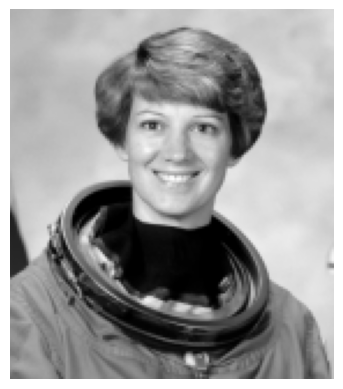

In [ ]:
test_image = data.astronaut()
test_image = color.rgb2gray(test_image)
test_image = transform.rescale(test_image, 0.5)
test_image = test_image[:160, 40:180]

plt.imshow(test_image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
def sliding_window(
    image: np.array,
    patch_size: tuple[int] = image_size,
    istep: int = 2,
    jstep: int = 2,
    scale: float = 1.0,
):
    """
    Generates image patches using a sliding window approach.
    """
    Ni, Nj = (int(scale * s) for s in patch_size)
    for i in range(0, image.shape[0] - Ni, istep):
        for j in range(0, image.shape[1] - Ni, jstep):
            patch = image[i:i + Ni, j:j + Nj]
            if scale != 1:
                patch = transform.resize(patch, patch_size)
            yield (i, j), patch

In [ ]:
test_img_stat = 'Test Image Inference'
res_stats.start_stats_profiling(test_img_stat)

indices, patches = zip(*sliding_window(test_image))
patches_feats = np.array([extract_features(patch, FEATURE_EXTRACTOR) for patch in tqdm(patches)])
patches_feats.shape

res_stats.stop_stats_profiling(test_img_stat)
res_stats.print_stats_profile(test_img_stat)


100%|██████████| 1911/1911 [00:01<00:00, 1477.57it/s]


---------- Test Image Inference Statistics ----------
|   Time Elaps. : 1.3 sec
|   CPU used : 47.2 %
|   RAM used : 0.0 GBs


In [ ]:
labels = model.predict(patches_feats)
proba = model.predict_proba(patches_feats)
labels.sum()

np.float64(6.0)

In [ ]:
def non_max_suppression(boxes, overlap_thresh=0.4):
    """
    Applies the Non-Maximum Suppression to the passed bounding boxes,
    based on the prediction score provided.

    """
    if len(boxes) == 0:
        return []

    # Coordinate conversion and area calculation
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    area = (x2 - x1 + 1) * (y2 - y1 + 1)

    # Sorting by confidence score
    idxs = np.argsort(boxes[:, 4])  # Ascending order confidence

    pick = []
    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        # Intersection over union calculation (IoU)
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        overlap = (w * h) / area[idxs[:last]]

        # Removing boxes with high overlap
        idxs = np.delete(idxs, np.concatenate(([last],
                        np.where(overlap > overlap_thresh)[0])))

    return boxes[pick]

In [ ]:
def plot_bboxes_on_image(image, bboxes, title: str):
    """Plots bounding boxes on an image for visualization."""
    fig, ax = plt.subplots()
    plt.title(title)
    ax.imshow(image, cmap='gray')
    ax.axis('off')
    for box in boxes:
        x1, y1, x2, y2, _ = box
        Ny, Nx = y2 - y1, x2 - x1
        ax.add_patch(plt.Rectangle((y1, x1), Ny, Nx, edgecolor='red', alpha=0.6, lw=2, facecolor='none'))

In [ ]:
# prediction probability threshold
# the default value is usually 0.5
threshold = 0.5

# create empty list of bounding boxes
boxes = []
Ni, Nj = image_size
for i, j in np.array(indices)[labels == 1]:
    # add new bounding box with coordinate x1, y1, x2, y2
    # where x1, y1 is the top-left corner and
    # x2, y2 is the bottom-right corner
    boxes.append((int(i), int(j), int(i) + Ni, int(j) + Nj))

# cast to tensor
boxes = np.array(boxes)

# indices where the face probability
# is above the provided threshold
proba_ids = np.where(proba[:,1] >= threshold)[0]

# create the bounding-box scores using the prediction probabilities
# it is important to provide the probabilities instead of the labels
# so that the NMS algorithm can use the `proba` to discriminate
# some bounding boxes and select others
bscores = proba[proba_ids][:,1] # 1 is to get the column of the `face` class

# add the scores to the boxes
boxes = np.c_[boxes, bscores]

(6, 5)


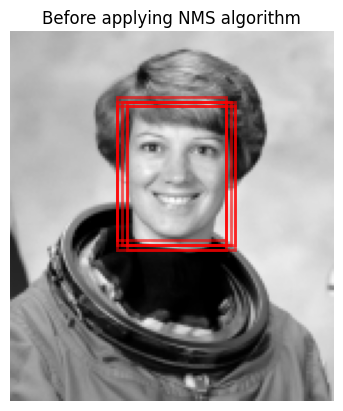

In [ ]:
# plot the bounding boxes without the NMS
print(f'{boxes.shape}')
plot_bboxes_on_image(test_image, boxes, f'Before applying NMS algorithm')


(1, 5)


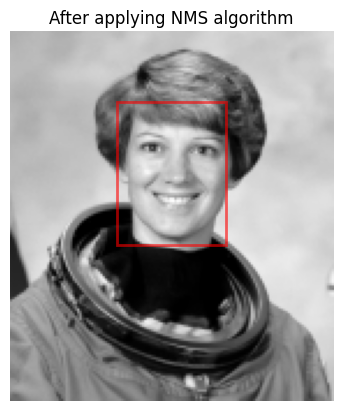

In [ ]:
# apply the NMS algorithm to remove overlapped bboxes
boxes = non_max_suppression(np.array(boxes))
print(f'\n{boxes.shape}')
plot_bboxes_on_image(test_image, boxes, f'After applying NMS algorithm')

### Evaluate on Olivetti Dataset

We now collect another Faces' dataset which contains out-of-sample images. In this case, Scikit-Learn provides the Olivetti dataset containing 400 different face images.

The purpose of this experiment is to evaluate the extrapolation capabilities of the trained MLP Classifier on an out-of-distribution data.


In [ ]:
olv_data_stat = 'Olivetti Dataset Gathering'
res_stats.start_stats_profiling(olv_data_stat)

# download the olivetti dataset, if it has not been done before
olv_dataset = fetch_olivetti_faces()

res_stats.stop_stats_profiling(olv_data_stat)
res_stats.print_stats_profile(olv_data_stat)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data

---------- Olivetti Dataset Gathering Statistics ----------
|   Time Elaps. : 1.63 sec
|   CPU used : -1.3 %
|   RAM used : 0.01 GBs


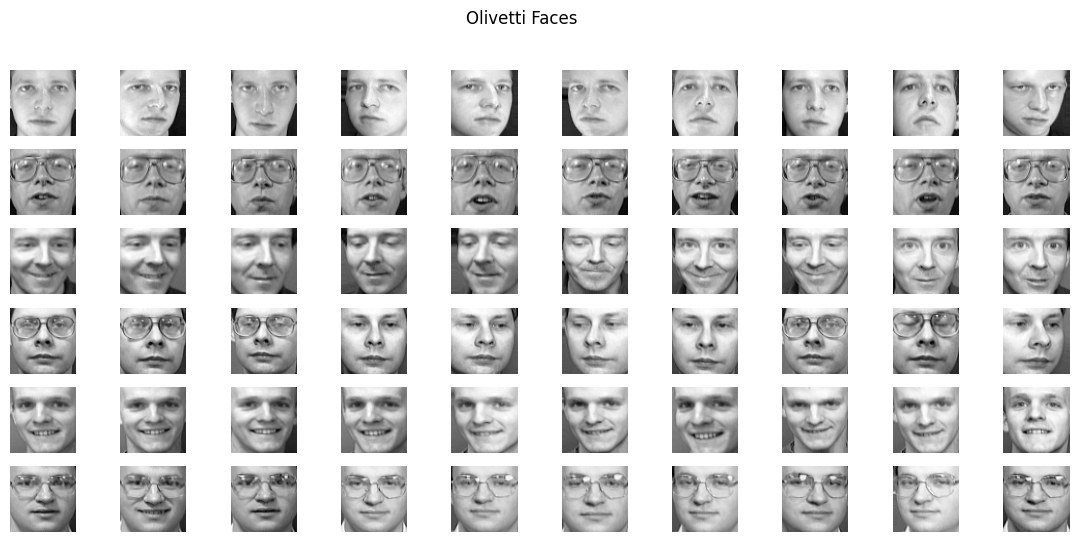

In [ ]:
fig, ax = plt.subplots(6, 10, figsize=(14,6))
fig.suptitle(f'Olivetti Faces')
for i, axi in enumerate(ax.flat):
    axi.imshow(olv_dataset['images'][i], cmap='gray')
    axi.axis('off')

In [ ]:
olv_inf_stat = 'Olivetti Dataset Inference'
res_stats.start_stats_profiling(olv_inf_stat)

# get the HOG transformed features from the images
image_feats = np.array([
    extract_features(resize(image, image_size), FEATURE_EXTRACTOR)
    for image in tqdm(list(olv_dataset['images']))
])

# scale the features with the fitted scaler
image_feats = scaler.transform(image_feats)

# predict the labels and print the results
labels = model.predict(image_feats)
print(f'Percentage of True Positives on the Olivetti Dataset: {(sum(labels) / len(labels)) * 100} %')

res_stats.stop_stats_profiling(olv_inf_stat)
res_stats.print_stats_profile(olv_inf_stat)

100%|██████████| 400/400 [00:00<00:00, 1079.36it/s]

Percentage of True Positives on the Olivetti Dataset: 96.75 %

---------- Olivetti Dataset Inference Statistics ----------
|   Time Elaps. : 0.38 sec
|   CPU used : 27.2 %
|   RAM used : 0.0 GBs


In [ ]:
total_running_time = res_stats.program_end()
print(f'Program Ended. Total execution time is {total_running_time} seconds')

Program Ended. Total execution time is 150.10795760154724 seconds


Now we plot the RAM and CPU usages throughout the Jupyter Notebook execution. Note that the RAM values comprise also the initial RAM value, i.e. `BASE_RAM_JUPYTER_NOTEBOOK`. Hence, if we want to analyze only the RAM used by the executed cells, we have to subtract the `BASE_RAM_JUPYTER_NOTEBOOK` RAM.

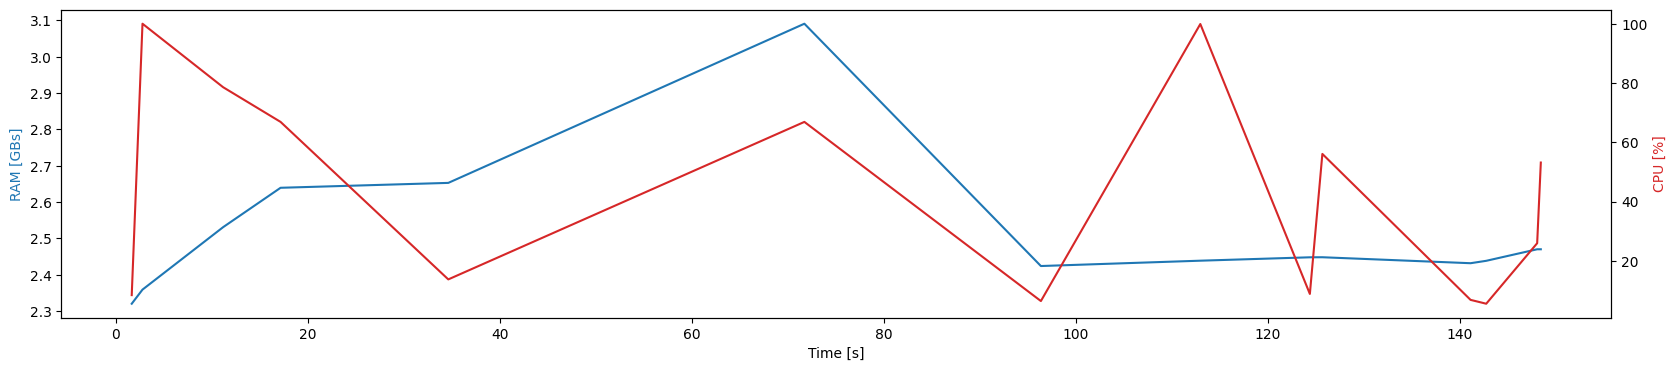

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(20,4))
tax = ax.twinx()
ax.plot([float(sec) for sec in res_stats.ram_usage.keys()], res_stats.ram_usage.values(), color='tab:blue')
ax.set_ylabel('RAM [GBs]', color='tab:blue')
ax.set_xlabel('Time [s]')

tax.plot([float(sec) for sec in res_stats.cpu_percent.keys()], res_stats.cpu_percent.values(), color='tab:red')
tax.set_ylabel('CPU [%]', color='tab:red')

plt.show()

**5. Store the Results to Disk 5**


Now that we hava a full ML pipeline, we can store the resulting ML model along with the StandardScaler that is used to standardize the data before going in input to the model.

In [ ]:
import pickle

# store the ML model as a pickle dump
with open('model.pkl', 'wb') as handle:
    pickle.dump(obj=model, file=handle)

# store the ML scaler as a pickle dump
with open('scaler.pkl', 'wb') as handle:
    pickle.dump(obj=scaler, file=handle)


In [ ]:
# test the opening of the saved files
with open('model.pkl', 'rb') as handle:
    m = pickle.load(handle)
m

MLPClassifier(hidden_layer_sizes=(64, 128, 64), max_iter=100, verbose=True)

In [ ]:
# test the opening of the saved files
with open('scaler.pkl', 'rb') as handle:
    s = pickle.load(handle)
s

StandardScaler()

**6. Bibliographic Research**

D, A. (2022, December 6). Computer Vision: Viola-Jones Object Detection. Medium. https://medium.com/@Andrew_D./computer-vision-viola-jones-object-detection-d2a609527b7c

Great Learning. (2024, September 2). Face Detection using Viola Jones Algorithm. Great Learning Blog: Free Resources What Matters to Shape Your Career! https://www.mygreatlearning.com/blog/viola-jones-algorithm/

Hatem, H., Beiji, Z., & Majeed, R. (2015). A survey of feature base methods for human face detection. International Journal of Control and Automation, 8(5), 61–78. https://doi.org/10.14257/ijca.2015.8.5.07

Sciforce. (2021, June 17). Face Detection Explained: State-of-the-Art Methods and Best Tools. Medium. https://medium.com/sciforce/face-detection-explained-state-of-the-art-methods-and-best-tools-f730fca16294

Viola, P., & Jones, M. (2001). Rapid object detection using a boosted cascade of simple features. Procedures of CVPR, 1, 511–518. https://doi.org/10.1109/cvpr.2001.990517

Yang, N. M., Kriegman, D., & Ahuja, N. (2002). Detecting faces in images: a survey. IEEE Transactions on Pattern Analysis and Machine Intelligence, 24(1), 34–58. https://doi.org/10.1109/34.982883

Aggarwal and Guha, 2024 - FDLite - A Single Stage Lightweight Face Detector Network.

Aliyu et al., 2022 - A Comparative Study of Eigenface and Fisherface Algorithms Based on OpenCV and Sci-kit Libraries Implementations.

Balaji and Priyanka, 2025 - A Comparative Study of Lightweight Face Detection Models for Real-Time Mobile Applications.

Bohara, 2020 Thesis - Artificial Intelligence and Machine Learning.

Hassanpour and Jowsari, 2023 - Lightweight Face Recognition - An Improved MobileFaceNet Model.

Kim et al., 2025 - Featherface - Robust and Lightweight Face Detection via Optimal Feature Integration.

Sroison et al., 2022 - Face Mask Detection using Machine Learning.


